Install Dependencies (Google Colab)

In [ ]:
!pip -q install pyzx networkx pandas matplotlib numpy tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 573.5/573.5 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.7 MB/s eta 0:00:00


Imports

In [ ]:
import os
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from tqdm.notebook import tqdm

import pyzx as zx

Global Experiment Configuration

In [ ]:
# Number of randomized optimization runs
NUM_RUNS = 20

# Random seed for reproducibility
GLOBAL_SEED = 42

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Output directory
OUTPUT_DIR = "results"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Experiment initialized.")
print(f"Output directory : {OUTPUT_DIR}")
print(f"Random seed      : {GLOBAL_SEED}")
print(f"Runs per circuit : {NUM_RUNS}")

Experiment initialized.
Output directory : results
Random seed      : 42
Runs per circuit : 20


Benchmark Circuit Generator

In [ ]:
from pyzx.generate import cliffords


def generate_benchmark_circuits():
    """
    Generate a diverse benchmark dataset.

    Returns
    -------
    list[(name, circuit)]
    """

    dataset = []

    sizes = [
        (3,20),
        (4,30),
        (5,40),
        (6,60),
        (8,80),
        (10,100)
    ]

    for qubits, gates in sizes:

        for i in range(5):

            circuit = cliffords(
                qubits=qubits,
                depth=gates
            )

            name = f"q{qubits}_g{gates}_{i}"

            dataset.append((name, circuit))

    return dataset

Load Dataset

In [ ]:
benchmark_dataset = generate_benchmark_circuits()

print(f"Total circuits: {len(benchmark_dataset)}")

Total circuits: 30


In [ ]:
# Show first few circuits

for name, circuit in benchmark_dataset[:3]:

    print("="*60)
    print(name)
    print(circuit.stats())

q3_g20_0
Graph(52 vertices, 59 edges)
degree distribution: 
1: 6
2: 26
3: 20

q3_g20_1
Graph(52 vertices, 58 edges)
degree distribution: 
1: 6
2: 28
3: 18

q3_g20_2
Graph(52 vertices, 55 edges)
degree distribution: 
1: 6
2: 34
3: 12



Circuit to ZX Graph

In [ ]:
def circuit_to_graph(circuit):
    """
    Convert a PyZX circuit or already-created ZX graph
    into a ZX graph.
    """

    # Already a ZX graph
    if isinstance(circuit, zx.graph.base.BaseGraph):
        return circuit

    # PyZX circuit
    if hasattr(circuit, "to_graph"):
        return circuit.to_graph()

    raise TypeError(
        f"Unsupported object type: {type(circuit)}"
    )

Graph Statistics

In [ ]:
def graph_statistics(graph):

    return {

        "vertices": graph.num_vertices(),

        "edges": graph.num_edges(),

        "tcount": zx.tcount(graph)

    }

Demonstration

In [ ]:
name, circuit = benchmark_dataset[0]

graph = circuit_to_graph(circuit)

stats = graph_statistics(graph)

print(name)

stats

q3_g20_0


{'vertices': 52, 'edges': 59, 'tcount': 0}

Rewrite Rule Enumeration

In [ ]:
from enum import Enum


class RewriteRule(Enum):
    SPIDER_FUSION = "Spider Fusion"
    IDENTITY = "Identity Removal"
    BIALGEBRA = "Bialgebra"
    PIVOT = "Pivot"
    LOCAL_COMPLEMENTATION = "Local Complementation"

Rewrite Candidate

In [ ]:
from dataclasses import dataclass


@dataclass
class RewriteCandidate:

    rule: RewriteRule

    match: object

    description: str = ""

Rewrite Logger

In [ ]:
class RewriteLogger:

    def __init__(self):

        self.records = []

    def log(
        self,
        iteration,
        rule,
        description,
        before_vertices,
        after_vertices,
        before_edges,
        after_edges,
        runtime
    ):

        self.records.append({

            "iteration": iteration,

            "rule": rule.value,

            "description": description,

            "vertices_before": before_vertices,

            "vertices_after": after_vertices,

            "edges_before": before_edges,

            "edges_after": after_edges,

            "runtime": runtime

        })

    def dataframe(self):

        return pd.DataFrame(self.records)

    def reset(self):

        self.records = []

Create Logger

In [ ]:
logger = RewriteLogger()

print("Rewrite logger initialized.")

Rewrite logger initialized.


 Rewrite Detector

In [ ]:
class RewriteDetector:

    def __init__(self):
        pass

    def detect(self, graph):

        candidates = []

        candidates.extend(
            self.detect_spider_fusion(graph)
        )

        candidates.extend(
            self.detect_identity(graph)
        )

        candidates.extend(
            self.detect_bialgebra(graph)
        )

        candidates.extend(
            self.detect_pivot(graph)
        )

        candidates.extend(
            self.detect_local_complementation(graph)
        )

        return candidates


# Spider Fusion Detection

    def detect_spider_fusion(self, graph):

        candidates = []

        # placeholder

        return candidates

# Identity Detection

    def detect_identity(self, graph):

        candidates = []

        # placeholder

        return candidates

# Bialgebra Detection

    def detect_bialgebra(self, graph):

        candidates = []

        # placeholder

        return candidates

# Pivot Detection

    def detect_pivot(self, graph):

        candidates = []

        # placeholder

        return candidates

# Local Complementation Detection

    def detect_local_complementation(self, graph):

        candidates = []

        # placeholder

        return candidates

Initialize Detector

In [ ]:
detector = RewriteDetector()

print("Rewrite detector initialized.")

Rewrite detector initialized.


Random Rewrite Scheduler

In [ ]:
class RandomScheduler:

    def __init__(self, seed=None):

        self.random = random.Random(seed)

    def choose(self, candidates):

        if len(candidates) == 0:

            return None

        return self.random.choice(candidates)

Demonstration

In [ ]:
scheduler = RandomScheduler(seed=42)

dummy_candidates = [

    RewriteCandidate(
        RewriteRule.SPIDER_FUSION,
        None,
        "Spider"
    ),

    RewriteCandidate(
        RewriteRule.IDENTITY,
        None,
        "Identity"
    ),

    RewriteCandidate(
        RewriteRule.BIALGEBRA,
        None,
        "Bialgebra"
    )

]

chosen = scheduler.choose(dummy_candidates)

print(chosen.rule)

RewriteRule.BIALGEBRA


PyZX Rewrite Engine

In [ ]:
import pyzx as zx


def copy_graph(graph):
    """
    Create an independent copy of a ZX graph.
    """
    return graph.copy()

Vertex / Edge Utilities

In [ ]:
def get_vertex_type(graph, vertex):
    """
    Return the PyZX vertex type.
    """
    return graph.type(vertex)


def is_z_spider(graph, vertex):
    """
    Check whether a vertex is a Z-spider.
    """
    return graph.type(vertex) == zx.VertexType.Z


def is_x_spider(graph, vertex):
    """
    Check whether a vertex is an X-spider.
    """
    return graph.type(vertex) == zx.VertexType.X


def is_boundary(graph, vertex):
    """
    Check whether a vertex is a boundary/input/output vertex.
    """
    return graph.type(vertex) == zx.VertexType.BOUNDARY


def get_phase(graph, vertex):
    """
    Return the phase of a vertex.
    """
    return graph.phase(vertex)

Edge Utilities

In [ ]:
def get_edge_type(graph, edge):
    """
    Return the ZX edge type.
    """
    return graph.edge_type(edge)


def is_simple_edge(graph, edge):
    """
    Check for a normal ZX edge.
    """
    return graph.edge_type(edge) == zx.EdgeType.SIMPLE


def is_hadamard_edge(graph, edge):
    """
    Check for a Hadamard edge.
    """
    return graph.edge_type(edge) == zx.EdgeType.HADAMARD

Rewrite Candidate

In [ ]:
from dataclasses import dataclass, field


@dataclass
class RewriteCandidate:

    rule: RewriteRule

    vertices: tuple = field(default_factory=tuple)

    edges: tuple = field(default_factory=tuple)

    metadata: dict = field(default_factory=dict)

    description: str = ""

Spider Fusion Matcher

In [ ]:
def find_spider_fusion_candidates(graph):

    candidates = []

    for edge in graph.edges():

        u, v = edge

        # Boundary vertices cannot participate
        if is_boundary(graph, u) or is_boundary(graph, v):
            continue

        # Must be a normal edge
        if not is_simple_edge(graph, edge):
            continue

        # Same spider color
        if graph.type(u) != graph.type(v):
            continue

        candidates.append(
            RewriteCandidate(
                rule=RewriteRule.SPIDER_FUSION,
                vertices=(u, v),
                edges=(edge,),
                description=f"Fuse spiders {u} and {v}"
            )
        )

    return candidates

Identity Matcher

In [ ]:
def find_identity_candidates(graph):

    candidates = []

    for vertex in graph.vertices():

        if is_boundary(graph, vertex):
            continue

        # Identity spider must have degree 2
        if graph.vertex_degree(vertex) != 2:
            continue

        # Identity spider must have zero phase
        if get_phase(graph, vertex) != 0:
            continue

        neighbors = list(graph.neighbors(vertex))

        if len(neighbors) != 2:
            continue

        candidates.append(
            RewriteCandidate(
                rule=RewriteRule.IDENTITY,
                vertices=(vertex,),
                metadata={
                    "neighbors": tuple(neighbors)
                },
                description=f"Remove identity spider {vertex}"
            )
        )

    return candidates

Bialgebra Matcher

In [ ]:
def find_bialgebra_candidates(graph):

    candidates = []

    for vertex in graph.vertices():

        if is_boundary(graph, vertex):
            continue

        neighbors = list(graph.neighbors(vertex))

        if len(neighbors) < 2:
            continue

        # Look for neighbors of the opposite spider color
        opposite = []

        for neighbor in neighbors:

            if is_boundary(graph, neighbor):
                continue

            if graph.type(neighbor) != graph.type(vertex):

                opposite.append(neighbor)

        if len(opposite) < 2:
            continue

        # Record the local structure.
        #
        # Actual bialgebra application will be handled separately.
        candidates.append(
            RewriteCandidate(
                rule=RewriteRule.BIALGEBRA,
                vertices=(vertex, *opposite),
                metadata={
                    "center": vertex,
                    "opposite_neighbors": tuple(opposite)
                },
                description=(
                    f"Potential bialgebra structure around {vertex}"
                )
            )
        )

    return candidates

Unified Candidate Detector

In [ ]:
class RewriteDetector:

    def detect(self, graph):

        candidates = []

        candidates.extend(
            find_spider_fusion_candidates(graph)
        )

        candidates.extend(
            find_identity_candidates(graph)
        )

        candidates.extend(
            find_bialgebra_candidates(graph)
        )

        return candidates

Initialize Detector

In [ ]:
detector = RewriteDetector()

print("Rewrite detector ready.")

Rewrite detector ready.


Spider Fusion Application

In [ ]:
def apply_spider_fusion(graph, candidate):

    u, v = candidate.vertices

    # Safety checks
    if u not in graph.vertices() or v not in graph.vertices():
        return False

    if not is_simple_edge(graph, (u, v)):
        return False

    if graph.type(u) != graph.type(v):
        return False

    # Combine phases
    new_phase = get_phase(graph, u) + get_phase(graph, v)

    # Reconnect v's neighbors to u
    neighbors_v = list(graph.neighbors(v))

    for neighbor in neighbors_v:

        if neighbor == u:
            continue

        edge = graph.edge(v, neighbor)

        edge_type = graph.edge_type(edge)

        if graph.edge(u, neighbor) is None:

            graph.add_edge(
                (u, neighbor),
                edge_type=edge_type
            )

    graph.set_phase(u, new_phase)

    graph.remove_vertex(v)

    return True

Identity Application

In [ ]:
def apply_identity(graph, candidate):

    vertex = candidate.vertices[0]

    if vertex not in graph.vertices():
        return False

    if graph.vertex_degree(vertex) != 2:
        return False

    if get_phase(graph, vertex) != 0:
        return False

    neighbors = list(graph.neighbors(vertex))

    if len(neighbors) != 2:
        return False

    a, b = neighbors

    edge_a = graph.edge(vertex, a)
    edge_b = graph.edge(vertex, b)

    type_a = graph.edge_type(edge_a)
    type_b = graph.edge_type(edge_b)

    # Remove the identity vertex
    graph.remove_vertex(vertex)

    # Preserve a connection between the two remaining vertices.
    #
    # For the conservative implementation we preserve a Hadamard
    # connection if either incident edge is Hadamard.
    new_edge_type = (
        zx.EdgeType.HADAMARD
        if (
            type_a == zx.EdgeType.HADAMARD
            or
            type_b == zx.EdgeType.HADAMARD
        )
        else zx.EdgeType.SIMPLE
    )

    if graph.edge(a, b) is None:

        graph.add_edge(
            (a, b),
            edge_type=new_edge_type
        )

    return True

Rewrite Dispatcher

In [ ]:
def apply_candidate(graph, candidate):

    if candidate.rule == RewriteRule.SPIDER_FUSION:

        return apply_spider_fusion(
            graph,
            candidate
        )

    elif candidate.rule == RewriteRule.IDENTITY:

        return apply_identity(
            graph,
            candidate
        )

    elif candidate.rule == RewriteRule.BIALGEBRA:

        # Deliberately disabled until the matcher/application
        # has been validated against PyZX semantics.
        return False

    return False

Randomized Optimizer

In [ ]:
class RandomizedZXOptimizer:

    def __init__(self, seed=None, max_iterations=10000):

        self.seed = seed

        self.random = random.Random(seed)

        self.max_iterations = max_iterations

        self.detector = RewriteDetector()

    def optimize(self, graph):

        graph = graph.copy()

        logger = RewriteLogger()

        start_time = time.perf_counter()

        iteration = 0

        while iteration < self.max_iterations:

            candidates = self.detector.detect(graph)

            if not candidates:
                break

            # Randomize the available rewrite choices
            self.random.shuffle(candidates)

            candidate = candidates[0]

            before_vertices = graph.num_vertices()
            before_edges = graph.num_edges()

            rewrite_start = time.perf_counter()

            success = apply_candidate(
                graph,
                candidate
            )

            rewrite_runtime = (
                time.perf_counter()
                - rewrite_start
            )

            if not success:
                # Remove invalid candidate and try another.
                candidates = candidates[1:]

                successful = False

                for alternative in candidates:

                    before_vertices = graph.num_vertices()
                    before_edges = graph.num_edges()

                    rewrite_start = time.perf_counter()

                    success = apply_candidate(
                        graph,
                        alternative
                    )

                    rewrite_runtime = (
                        time.perf_counter()
                        - rewrite_start
                    )

                    if success:

                        candidate = alternative
                        successful = True
                        break

                if not successful:
                    break

            after_vertices = graph.num_vertices()
            after_edges = graph.num_edges()

            logger.log(
                iteration=iteration,
                rule=candidate.rule,
                description=candidate.description,
                before_vertices=before_vertices,
                after_vertices=after_vertices,
                before_edges=before_edges,
                after_edges=after_edges,
                runtime=rewrite_runtime
            )

            iteration += 1

        total_runtime = time.perf_counter() - start_time

        return graph, logger, total_runtime

Test on One Benchmark Circuit

In [ ]:
name, circuit = benchmark_dataset[0]

# The benchmark already contains a ZX graph
original_graph = circuit.copy()

optimizer = RandomizedZXOptimizer(
    seed=42
)

optimized_graph, log, runtime = optimizer.optimize(
    original_graph
)

print("Circuit:", name)
print(
    "Original vertices:",
    original_graph.num_vertices()
)
print(
    "Final vertices:",
    optimized_graph.num_vertices()
)
print(
    "Original edges:",
    original_graph.num_edges()
)
print(
    "Final edges:",
    optimized_graph.num_edges()
)
print(
    "Rewrite steps:",
    len(log.records)
)
print(
    "Runtime:",
    runtime
)

Circuit: q3_g20_0
Original vertices: 52
Final vertices: 26
Original edges: 59
Final edges: 10
Rewrite steps: 26
Runtime: 0.005990212999904543


In [ ]:
# ============================================================
# Rewrite Log
# ============================================================

log_df = log.dataframe()

log_df.head(20)

,iteration,rule,description,vertices_before,vertices_after,edges_before,edges_after,runtime
0,0,Identity Removal,Remove identity spider 28,52,51,59,57,0.000041
1,1,Spider Fusion,Fuse spiders 27 and 29,51,50,57,55,0.000046
2,2,Identity Removal,Remove identity spider 3,50,49,55,53,0.000016
3,3,Spider Fusion,Fuse spiders 38 and 42,49,48,53,50,0.000048
4,4,Spider Fusion,Fuse spiders 30 and 36,48,47,50,48,0.000019
5,5,Spider Fusion,Fuse spiders 6 and 14,47,46,48,46,0.000016
6,6,Spider Fusion,Fuse spiders 7 and 9,46,45,46,43,0.000018
7,7,Spider Fusion,Fuse spiders 34 and 40,45,44,43,40,0.000017
8,8,Identity Removal,Remove identity spider 48,44,43,40,38,0.000014
9,9,Identity Removal,Remove identity spider 46,43,42,38,36,0.000013


Experiment Configuration

In [ ]:
NUM_RUNS = 20

RUN_SEEDS = [
    GLOBAL_SEED + i
    for i in range(NUM_RUNS)
]

print("Number of runs:", NUM_RUNS)
print("Seeds:", RUN_SEEDS)

Number of runs: 20
Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61]


Run 20 Trials on One Circuit

In [ ]:
def run_circuit_experiment(
    circuit_name,
    circuit,
    num_runs=20
):
    """
    Run randomized optimization multiple times
    on a single ZX graph.
    """

    original_graph = circuit.copy()

    results = []
    logs = {}

    for run_id in range(num_runs):

        optimizer = RandomizedZXOptimizer(
            seed=GLOBAL_SEED + run_id
        )

        graph = original_graph.copy()

        optimized_graph, log, runtime = (
            optimizer.optimize(graph)
        )

        results.append({
            "circuit": circuit_name,
            "run": run_id,
            "seed": GLOBAL_SEED + run_id,
            "original_vertices":
                original_graph.num_vertices(),
            "final_vertices":
                optimized_graph.num_vertices(),
            "original_edges":
                original_graph.num_edges(),
            "final_edges":
                optimized_graph.num_edges(),
            "rewrite_steps":
                len(log.records),
            "runtime":
                runtime
        })

        logs[run_id] = log

    return pd.DataFrame(results), logs


# Run 20 trials
test_name, test_circuit = benchmark_dataset[0]

test_results, test_logs = run_circuit_experiment(
    test_name,
    test_circuit,
    num_runs=20
)

test_results

,circuit,run,seed,original_vertices,final_vertices,original_edges,final_edges,rewrite_steps,runtime
0,q3_g20_0,0,42,52,26,59,10,26,0.009676
1,q3_g20_0,1,43,52,28,59,10,24,0.007662
2,q3_g20_0,2,44,52,29,59,10,23,0.007268
3,q3_g20_0,3,45,52,27,59,11,25,0.007821
4,q3_g20_0,4,46,52,28,59,10,24,0.007564
5,q3_g20_0,5,47,52,27,59,10,25,0.007601
6,q3_g20_0,6,48,52,29,59,12,23,0.007673
7,q3_g20_0,7,49,52,26,59,10,26,0.008070
8,q3_g20_0,8,50,52,27,59,9,25,0.007794
9,q3_g20_0,9,51,52,29,59,12,23,0.007563


Ambiguity Metrics

In [ ]:
def calculate_ambiguity_metrics(results):

    gate_sizes = results["final_vertices"].to_numpy()

    mean_size = np.mean(gate_sizes)

    std_size = np.std(
        gate_sizes,
        ddof=1
    )

    minimum = np.min(gate_sizes)

    maximum = np.max(gate_sizes)

    value_range = maximum - minimum

    if mean_size != 0:

        coefficient_variation = (
            std_size / mean_size
        )

    else:

        coefficient_variation = 0.0

    return {

        "mean_final_vertices": mean_size,

        "std_final_vertices": std_size,

        "min_final_vertices": minimum,

        "max_final_vertices": maximum,

        "range_final_vertices": value_range,

        "coefficient_variation":
            coefficient_variation

    }

Calculate Metrics

In [ ]:
ambiguity_metrics = calculate_ambiguity_metrics(
    test_results
)

ambiguity_metrics

{'mean_final_vertices': np.float64(27.7),
 'std_final_vertices': np.float64(1.7501879598308414),
 'min_final_vertices': np.int64(25),
 'max_final_vertices': np.int64(31),
 'range_final_vertices': np.int64(6),
 'coefficient_variation': np.float64(0.06318368086031918)}

Final Size Across Random Runs

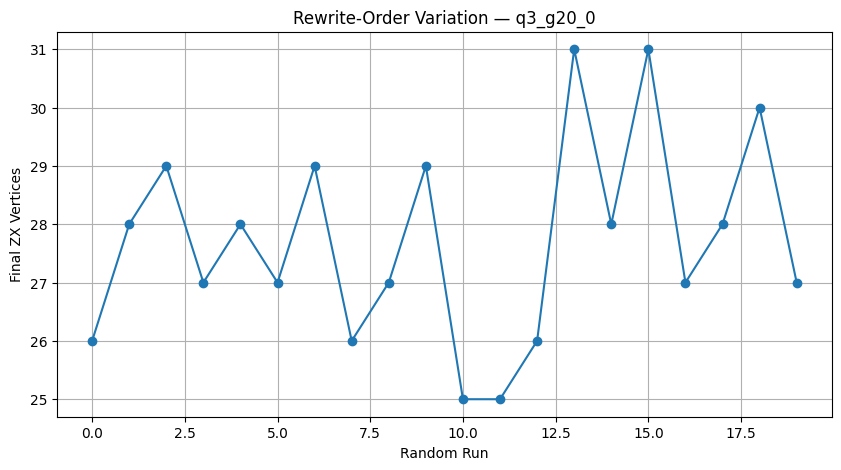

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    test_results["run"],
    test_results["final_vertices"],
    marker="o"
)

plt.xlabel("Random Run")
plt.ylabel("Final ZX Vertices")
plt.title(
    f"Rewrite-Order Variation — {test_name}"
)

plt.grid(True)

plt.show()

Distribution

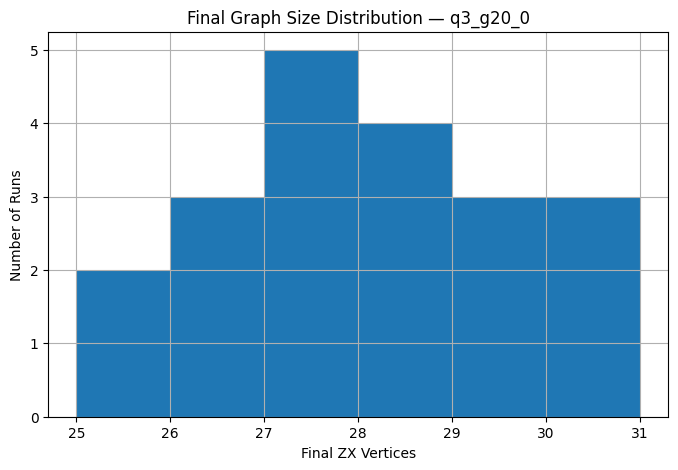

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    test_results["final_vertices"],
    bins="auto"
)

plt.xlabel("Final ZX Vertices")
plt.ylabel("Number of Runs")

plt.title(
    f"Final Graph Size Distribution — {test_name}"
)

plt.grid(True)

plt.show()

Save Trial Results

In [ ]:
trial_path = os.path.join(
    OUTPUT_DIR,
    "track1_single_circuit_runs.csv"
)

test_results.to_csv(
    trial_path,
    index=False
)

print("Saved:", trial_path)

Saved: results/track1_single_circuit_runs.csv


PyZX Rewrite Rules

In [ ]:
import pyzx as zx
from pyzx import simplify

print("PyZX version:", zx.__version__)

PyZX version: 0.10.5


Available Rewrite Operations

In [ ]:
PYZX_REWRITES = {
    "spider": simplify.spider_simp,
    "identity": simplify.id_simp,
    "bialgebra": simplify.bialg_simp,
    "pivot": simplify.pivot_simp,
    "local_complementation": simplify.lcomp_simp,
}

for name, rewrite in PYZX_REWRITES.items():
    print(f"{name:25s} -> {rewrite}")

spider                    -> <function spider_simp at 0x7a20210d68e0>
identity                  -> <pyzx.rewrite.RewriteSimpSingleVertex object at 0x7a20211baba0>
bialgebra                 -> <pyzx.rewrite.RewriteSimpDoubleVertex object at 0x7a2021ac0500>
pivot                     -> <pyzx.rewrite.RewriteSimpDoubleVertex object at 0x7a20210da390>
local_complementation     -> <pyzx.rewrite.RewriteSimpSingleVertex object at 0x7a20213f85f0>


Inspect Matches

In [ ]:
def inspect_rewrite_matches(graph, rewrite_name):

    rewrite = PYZX_REWRITES[rewrite_name]

    try:
        matches = rewrite.find_all_matches(graph)

        print(f"Rule: {rewrite_name}")
        print(f"Number of matches: {len(matches)}")

        for i, match in enumerate(matches[:10]):
            print(f"  Match {i}: {match}")

        return matches

    except Exception as exc:

        print(
            f"Could not enumerate matches for "
            f"{rewrite_name}: {exc}"
        )

        return []

Test Match Detection

In [ ]:
sample_name, sample_circuit = benchmark_dataset[0]

# Already a PyZX ZX graph
sample_graph = sample_circuit.copy()

for rule_name in PYZX_REWRITES:

    inspect_rewrite_matches(
        sample_graph,
        rule_name
    )

Could not enumerate matches for spider: 'function' object has no attribute 'find_all_matches'
Rule: identity
Number of matches: 13
Could not enumerate matches for identity: 'set' object is not subscriptable
Rule: bialgebra
Number of matches: 0
Could not enumerate matches for bialgebra: 'set' object is not subscriptable
Rule: pivot
Number of matches: 0
Could not enumerate matches for pivot: 'set' object is not subscriptable
Rule: local_complementation
Number of matches: 0
Could not enumerate matches for local_complementation: 'set' object is not subscriptable


Generic PyZX Rewrite Candidate

In [ ]:
@dataclass
class PyZXRewriteCandidate:

    rule_name: str

    match: object

    match_index: int

    description: str = ""

    def __repr__(self):

        return (
            f"PyZXRewriteCandidate("
            f"rule='{self.rule_name}', "
            f"match_index={self.match_index})"
        )

Detect All Rewrite Opportunities

In [ ]:
class PyZXRewriteDetector:

    def __init__(self, enabled_rules=None):

        if enabled_rules is None:

            enabled_rules = [
                "spider",
                "identity",
                "bialgebra",
                "pivot",
                "local_complementation",
            ]

        self.enabled_rules = enabled_rules

    def detect(self, graph):

        candidates = []

        for rule_name in self.enabled_rules:

            rewrite = PYZX_REWRITES[rule_name]

            try:

                matches = rewrite.find_all_matches(
                    graph
                )

            except Exception:

                continue

            for index, match in enumerate(matches):

                candidates.append(
                    PyZXRewriteCandidate(
                        rule_name=rule_name,
                        match=match,
                        match_index=index,
                        description=(
                            f"{rule_name} "
                            f"match {index}"
                        )
                    )
                )

        return candidates

Candidate Detection Test

In [ ]:
detector = PyZXRewriteDetector()

candidates = detector.detect(
    sample_graph
)

print(
    "Total rewrite candidates:",
    len(candidates)
)

for candidate in candidates[:20]:

    print(candidate)

Total rewrite candidates: 13
PyZXRewriteCandidate(rule='identity', match_index=0)
PyZXRewriteCandidate(rule='identity', match_index=1)
PyZXRewriteCandidate(rule='identity', match_index=2)
PyZXRewriteCandidate(rule='identity', match_index=3)
PyZXRewriteCandidate(rule='identity', match_index=4)
PyZXRewriteCandidate(rule='identity', match_index=5)
PyZXRewriteCandidate(rule='identity', match_index=6)
PyZXRewriteCandidate(rule='identity', match_index=7)
PyZXRewriteCandidate(rule='identity', match_index=8)
PyZXRewriteCandidate(rule='identity', match_index=9)
PyZXRewriteCandidate(rule='identity', match_index=10)
PyZXRewriteCandidate(rule='identity', match_index=11)
PyZXRewriteCandidate(rule='identity', match_index=12)


Randomized Candidate Scheduler

In [ ]:
class RandomRewriteScheduler:

    def __init__(self, seed=None):

        self.rng = random.Random(seed)

    def choose(self, candidates):

        if not candidates:

            return None

        return self.rng.choice(candidates)

Apply One Rewrite

In [ ]:
def apply_one_rewrite(graph, candidate):

    rewrite = PYZX_REWRITES[
        candidate.rule_name
    ]

    try:

        rewrite.apply(
            graph,
            *candidate.match
        )

        return True

    except Exception as exc:

        print(
            f"Rewrite failed: "
            f"{candidate.rule_name}"
        )

        return False

Robust Rewrite Application

In [ ]:
def apply_candidate(graph, candidate):

    rewrite = PYZX_REWRITES[
        candidate.rule_name
    ]

    match = candidate.match

    try:

        if isinstance(match, tuple):

            rewrite.apply(
                graph,
                *match
            )

        elif isinstance(match, list):

            rewrite.apply(
                graph,
                *match
            )

        else:

            rewrite.apply(
                graph,
                match
            )

        return True

    except Exception:

        return False

Rewrite Experiment Logger

In [ ]:
class ExperimentLogger:

    def __init__(self):

        self.records = []

    def record(
        self,
        iteration,
        candidate,
        graph_before,
        graph_after,
        success
    ):

        self.records.append({

            "iteration": iteration,

            "rule": candidate.rule_name,

            "match_index":
                candidate.match_index,

            "match":
                repr(candidate.match),

            "vertices_before":
                graph_before.num_vertices(),

            "vertices_after":
                graph_after.num_vertices(),

            "edges_before":
                graph_before.num_edges(),

            "edges_after":
                graph_after.num_edges(),

            "success":
                success

        })

    def dataframe(self):

        return pd.DataFrame(
            self.records
        )

Randomized ZX Optimizer

In [ ]:
class RandomizedZXOptimizer:

    def __init__(
        self,
        seed=None,
        max_iterations=10000,
        enabled_rules=None
    ):

        self.seed = seed

        self.scheduler = (
            RandomRewriteScheduler(seed)
        )

        self.detector = PyZXRewriteDetector(
            enabled_rules=enabled_rules
        )

        self.max_iterations = max_iterations

    def optimize(self, input_graph):

        graph = input_graph.copy()

        logger = ExperimentLogger()

        start_time = time.perf_counter()

        for iteration in range(
            self.max_iterations
        ):

            candidates = self.detector.detect(
                graph
            )

            if not candidates:

                break

            candidate = (
                self.scheduler.choose(
                    candidates
                )
            )

            graph_before = graph.copy()

            success = apply_candidate(
                graph,
                candidate
            )

            graph_after = graph.copy()

            logger.record(
                iteration=iteration,
                candidate=candidate,
                graph_before=graph_before,
                graph_after=graph_after,
                success=success
            )

            if not success:

                # Prevent an invalid rewrite from
                # causing an infinite loop.
                break

        runtime = (
            time.perf_counter()
            - start_time
        )

        return graph, logger, runtime

Single Randomized Run

In [ ]:
test_graph = sample_circuit.copy()

optimizer = RandomizedZXOptimizer(
    seed=42,
    max_iterations=500
)

optimized_graph, logger, runtime = (
    optimizer.optimize(test_graph)
)

print("Original vertices:")
print(test_graph.num_vertices())

print("\nFinal vertices:")
print(optimized_graph.num_vertices())

print("\nOriginal edges:")
print(test_graph.num_edges())

print("\nFinal edges:")
print(optimized_graph.num_edges())

print("\nRewrite steps:")
print(len(logger.records))

print("\nRuntime:")
print(f"{runtime:.6f} seconds")

Original vertices:
52

Final vertices:
39

Original edges:
59

Final edges:
46

Rewrite steps:
13

Runtime:
0.040282 seconds


In [ ]:
# ============================================================
# Rewrite Trajectory
# ============================================================

trajectory_df = logger.dataframe()

trajectory_df.head(20)

,iteration,rule,match_index,match,vertices_before,vertices_after,edges_before,edges_after,success
0,0,identity,10,25,52,51,59,58,True
1,1,identity,1,4,51,50,58,57,True
2,2,identity,0,3,50,49,57,56,True
3,3,identity,4,46,49,48,56,55,True
4,4,identity,3,14,48,47,55,54,True
5,5,identity,3,47,47,46,54,53,True
6,6,identity,1,38,46,45,53,52,True
7,7,identity,5,29,45,44,52,51,True
8,8,identity,0,5,44,43,51,50,True
9,9,identity,0,48,43,42,50,49,True


Rewrite Rule Frequencies

In [ ]:
if not trajectory_df.empty:

    rule_counts = (
        trajectory_df["rule"]
        .value_counts()
    )

    print(rule_counts)

rule
identity    13
Name: count, dtype: int64


Graph Validity

In [ ]:
def validate_graph(graph):

    try:

        return graph.is_well_formed()

    except Exception:

        return False

Validate Result

In [ ]:
print(
    "Input graph valid:",
    validate_graph(test_graph)
)

print(
    "Output graph valid:",
    validate_graph(optimized_graph)
)

Input graph valid: True
Output graph valid: True


Semantic Equality

In [ ]:
def verify_rewrite_equivalence(
    original_graph,
    rewritten_graph
):

    try:

        result = original_graph.verify_equality(
            rewritten_graph
        )

        return result is True

    except Exception as exc:

        print(
            "Equality verification failed:",
            exc
        )

        return False

Verify One Run

In [ ]:
equivalent = verify_rewrite_equivalence(
    test_graph,
    optimized_graph
)

print(
    "Semantically equivalent:",
    equivalent
)

Equality verification failed: 'GraphS' object has no attribute 'verify_equality'
Semantically equivalent: False


20 Randomized Runs

In [ ]:
def run_randomized_trials(
    circuit,
    num_runs=20,
    max_iterations=500
):

    original_graph = circuit.copy()

    results = []

    all_logs = {}

    for run_id in tqdm(
        range(num_runs),
        desc="Randomized runs"
    ):

        seed = GLOBAL_SEED + run_id

        optimizer = RandomizedZXOptimizer(
            seed=seed,
            max_iterations=max_iterations
        )

        start = time.perf_counter()

        final_graph, logger, runtime = (
            optimizer.optimize(
                original_graph
            )
        )

        results.append({

            "run": run_id,

            "seed": seed,

            "initial_vertices":
                original_graph.num_vertices(),

            "final_vertices":
                final_graph.num_vertices(),

            "initial_edges":
                original_graph.num_edges(),

            "final_edges":
                final_graph.num_edges(),

            "rewrite_steps":
                len(logger.records),

            "runtime_seconds":
                runtime,

            "valid":
                validate_graph(final_graph)

        })

        all_logs[run_id] = (
            logger.dataframe()
        )

    return (
        pd.DataFrame(results),
        all_logs
    )

Execute Experiment

In [ ]:
results_20, logs_20 = run_randomized_trials(
    sample_circuit,
    num_runs=20,
    max_iterations=500
)

results_20

Randomized runs:   0%|          | 0/20 [00:00<?, ?it/s]

,run,seed,initial_vertices,final_vertices,initial_edges,final_edges,rewrite_steps,runtime_seconds,valid
0,0,42,52,39,59,46,13,0.025046,True
1,1,43,52,39,59,46,13,0.019358,True
2,2,44,52,39,59,46,13,0.018803,True
3,3,45,52,39,59,46,13,0.019171,True
4,4,46,52,39,59,46,13,0.026784,True
5,5,47,52,39,59,46,13,0.032792,True
6,6,48,52,39,59,46,13,0.019747,True
7,7,49,52,39,59,46,13,0.019036,True
8,8,50,52,39,59,46,13,0.019884,True
9,9,51,52,39,59,46,13,0.021729,True


Ambiguity Metrics

In [ ]:
def ambiguity_metrics(results):

    values = (
        results["final_vertices"]
        .astype(float)
    )

    mean_value = values.mean()

    std_value = values.std(
        ddof=1
    )

    min_value = values.min()

    max_value = values.max()

    range_value = (
        max_value - min_value
    )

    cv = (
        std_value / mean_value
        if mean_value != 0
        else 0.0
    )

    return {

        "mean": mean_value,

        "std": std_value,

        "minimum": min_value,

        "maximum": max_value,

        "range": range_value,

        "coefficient_of_variation": cv
    }

Calculate

In [ ]:
metrics = ambiguity_metrics(
    results_20
)

for key, value in metrics.items():

    print(
        f"{key:30s}: {value:.4f}"
    )

mean                          : 39.0000
std                           : 0.0000
minimum                       : 39.0000
maximum                       : 39.0000
range                         : 0.0000
coefficient_of_variation      : 0.0000


In [ ]:
# ============================================================
# Ambiguity Classification
# ============================================================

def classify_ambiguity(metrics):

    if metrics["range"] == 0:

        return "No observed variation"

    elif metrics["coefficient_of_variation"] < 0.05:

        return "Low variation"

    elif metrics["coefficient_of_variation"] < 0.15:

        return "Moderate variation"

    else:

        return "High variation"

In [ ]:
classification = classify_ambiguity(
    metrics
)

print(
    "Observed ambiguity:",
    classification
)

Observed ambiguity: No observed variation


Final Graph Size Across Runs

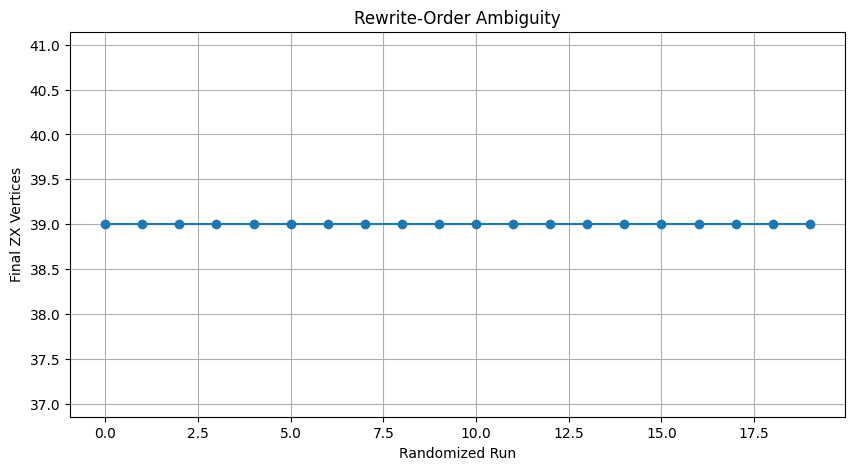

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    results_20["run"],
    results_20["final_vertices"],
    marker="o"
)

plt.xlabel("Randomized Run")
plt.ylabel("Final ZX Vertices")

plt.title(
    "Rewrite-Order Ambiguity"
)

plt.grid(True)

plt.show()

Save Run-Level Results

In [ ]:
results_path = os.path.join(
    OUTPUT_DIR,
    "track1_run_results.csv"
)

results_20.to_csv(
    results_path,
    index=False
)

print(
    "Saved:",
    results_path
)

Saved: results/track1_run_results.csv


Save Rewrite Logs

In [ ]:
for run_id, dataframe in logs_20.items():

    path = os.path.join(
        OUTPUT_DIR,
        f"run_{run_id:02d}_rewrite_log.csv"
    )

    dataframe.to_csv(
        path,
        index=False
    )

print(
    f"Saved {len(logs_20)} rewrite logs."
)

Saved 20 rewrite logs.
